# R7 — EKI-ModalPINN: how far downstream can 32 wall taps see?

**Diagnostic experiment, not a method build.** No neural-network retraining. Pure NumPy/SciPy,
CPU, runs in a few minutes.

## What this notebook measures

The project's open failure: every ModalPINN run collapses the oscillating modes (k≥1) toward
zero downstream while the near-cylinder region reconstructs acceptably. Eight steps of prior
diagnostics established that complete wake collapse costs only ~2.5% of the fluctuating tap
signal, and that a projected Hessian shows tap curvature **only** in the x/D≈1 band.

The proposal under test: instead of another physics loss term, apply an **ensemble Kalman
update** to a small set of modal correction parameters, using the 32 wall taps as observations.

$$\hat q_1^{\rm corrected}(x,y) = \alpha_1(x)\,\hat q_1^{\rm PINN}(x,y)\,e^{i(\delta k_x x + \delta\phi_0)},
\qquad \alpha_1(x)=\sum_m a_m B_m(x)$$

**The deliverable is a number:** the downstream distance in x/D at which the Kalman gain for
wake amplitude falls below the noise floor. A negative result is a legitimate outcome and is
reported as one.

## Sections

| § | Content |
|---|---|
| 1 | Setup: data, true modal decomposition, ω₀, PINN checkpoint, observation operator |
| 2 | Positive control — global α₁ (expected to succeed; does **not** bear on the open question) |
| 3 | **The actual test** — per-band amplitude observability vs downstream distance |
| 4 | Phase-gradient observability (the genuinely new measurement) |
| 5 | The Stage A / Stage B absorption defect, and whether a norm constraint fixes it |
| 6 | Verdict |

## Environment

Unlike the training notebooks (`E3_*`, `R2_*`…), this one needs **no TensorFlow, no GPU, no
Colab, no conda pin**. The trained ModalPINN weights are stored as plain complex arrays in
`DNN2_75_75_3_tanh.pickle`, so the network's forward pass is reimplemented in ~6 lines of NumPy.
Run it in any Python 3.8+ environment with numpy/scipy/matplotlib.

## 1. Setup

### 1.1 Paths and imports

`REPO` is the only path you may need to change. Everything else is derived from it.

In [1]:
import os, sys, pickle, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata, RegularGridInterpolator
from scipy.optimize import minimize_scalar
import scipy.sparse as sp
import scipy.sparse.linalg as spla

REPO = '/Users/mohammedhilal/Desktop/try/ModalPINN2.0'

DATA_RAW   = f'{REPO}/data/fixed_cylinder_atRe100'                       # 1.1 GB raw CFD text
FLOW_CACHE = f'{REPO}/enkf_pressure_only/evaluation/_flow_cache.npz'     # parsed cache (173 MB)
TAPS32     = f'{REPO}/data/sensor_indices/taps_32.npz'
CKPT       = (f'{REPO}/runs/R5_extracted/R5_k0_cv1_pressure_only_Re100_Nm3_Nint50000_Nmes5000'
              f'_WL25_Ntap32_FSBC_FIBC_BVF_lam0p1_K0_0p025_CV1_0p0075_seed0_20260806'
              f'/DNN2_75_75_3_tanh.pickle')

NMODES = 3          # k = 0,1,2,3 -> mean + 3 harmonics
RNG    = np.random.default_rng(0)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False, 'axes.spines.right': False})
print('numpy', np.__version__, '| scipy', __import__('scipy').__version__)
for pth, lab in [(DATA_RAW,'raw CFD'), (FLOW_CACHE,'flow cache'), (TAPS32,'32 taps'), (CKPT,'PINN checkpoint')]:
    print(f'{lab:18s} {"OK " if os.path.exists(pth) else "MISSING"}  {pth}')

numpy 2.5.0 | scipy 1.18.0
raw CFD            OK   /Users/mohammedhilal/Desktop/try/ModalPINN2.0/data/fixed_cylinder_atRe100
flow cache         OK   /Users/mohammedhilal/Desktop/try/ModalPINN2.0/enkf_pressure_only/evaluation/_flow_cache.npz
32 taps            OK   /Users/mohammedhilal/Desktop/try/ModalPINN2.0/data/sensor_indices/taps_32.npz
PINN checkpoint    OK   /Users/mohammedhilal/Desktop/try/ModalPINN2.0/runs/R5_extracted/R5_k0_cv1_pressure_only_Re100_Nm3_Nint50000_Nmes5000_WL25_Ntap32_FSBC_FIBC_BVF_lam0p1_K0_0p025_CV1_0p0075_seed0_20260806/DNN2_75_75_3_tanh.pickle


### 1.2 Load the 32 wall taps

These are the **only** observations any estimator in this notebook is allowed to use. Everything
else loaded below (the full velocity/pressure field) is used strictly for building the base modal
field and for evaluation.

In [2]:
taps = np.load(TAPS32)
tap_x, tap_y = taps['x'], taps['y']
tap_t        = taps['times']
tap_p        = taps['pressure']              # (201, 32)
tap_theta    = np.arctan2(tap_y, tap_x)
t0           = tap_t - tap_t[0]
Nt, NTAP     = tap_p.shape

r_tap = np.hypot(tap_x, tap_y)
print(f'{NTAP} taps, {Nt} snapshots, dt = {tap_t[1]-tap_t[0]:.3f}')
print(f'tap radius: {r_tap.min():.4f} to {r_tap.max():.4f}  (cylinder r_c = 0.5)')
print(f'tap pressure: mean {tap_p.mean():+.4f}, std {tap_p.std():.4f}')
print(f'  steady part (time-mean, varies over taps): std {tap_p.mean(0).std():.4f}')
print(f'  unsteady part (the wake signal)          : rms {(tap_p-tap_p.mean(0)).std():.4f}'
      f'   <- only {100*(tap_p-tap_p.mean(0)).std()/tap_p.std():.0f}% of the total')

32 taps, 201 snapshots, dt = 0.100
tap radius: 0.5000 to 0.5000  (cylinder r_c = 0.5)
tap pressure: mean -0.2415, std 0.3384
  steady part (time-mean, varies over taps): std 0.3351
  unsteady part (the wake signal)          : rms 0.0472   <- only 14% of the total


### 1.3 Recover the shedding frequency ω₀ from the taps

A raw FFT bin is too coarse here — 201 snapshots at dt=0.1 spans only ~3.3 shedding periods, so
the bin spacing is ~0.31 rad/time. We fit ω by nonlinear least squares on a truncated harmonic
series instead, which is not limited by bin resolution.

A lift-coefficient proxy is used as the fitting signal rather than a single tap, because tap 0
(front stagnation) is dominated by the **second** harmonic — a known finding from Stage A of the
EnKF study, and a trap worth avoiding.

In [3]:
order = np.argsort(tap_theta)
Cl_proxy = -np.sum(tap_p[:, order] * np.sin(tap_theta[order])[None, :], axis=1) * (2*np.pi/NTAP)

def harm_design(om, t, N=NMODES):
    cols = [np.ones_like(t)]
    for k in range(1, N+1):
        cols += [np.cos(k*om*t), np.sin(k*om*t)]
    return np.stack(cols, 1)

def harm_resid(om, S):
    A = harm_design(om, t0)
    c, *_ = np.linalg.lstsq(A, S, rcond=None)
    return float(np.sum((S - A@c)**2))

scan = np.linspace(0.8, 1.4, 1201)
om_seed = scan[np.argmin([harm_resid(o, Cl_proxy) for o in scan])]
OM0 = float(minimize_scalar(lambda o: harm_resid(o, tap_p),
                            bracket=(om_seed-0.02, om_seed, om_seed+0.02)).x)
St = OM0/(2*np.pi)
print(f'omega_0 (harmonic LSQ, all 32 taps, N={NMODES}) = {OM0:.4f}')
print(f'Strouhal number St = {St:.4f}')
print(f'  literature Re=100: St = 0.164-0.165        -> deviation {100*abs(St-0.1645)/0.1645:.1f}%')
print(f'  project constant omega_0 = 1.036 (St=0.1649) -> deviation {100*abs(OM0-1.036)/1.036:.2f}%')
T_shed = 2*np.pi/OM0
print(f'shedding period T = {T_shed:.3f}; record spans {t0[-1]/T_shed:.2f} periods')

omega_0 (harmonic LSQ, all 32 taps, N=3) = 1.0357
Strouhal number St = 0.1648
  literature Re=100: St = 0.164-0.165        -> deviation 0.2%
  project constant omega_0 = 1.036 (St=0.1649) -> deviation 0.03%
shedding period T = 6.066; record spans 3.30 periods


### 1.4 True modal decomposition

The convention throughout: a real field $q(x,y,t)$ is represented as

$$q(x,y,t) = \mathrm{Re}\Big[\textstyle\sum_{k=0}^{N} \hat q_k(x,y)\, e^{ik\omega_0 t}\Big]$$

with $\hat q_0$ real. Fitting by least squares at known ω₀ (rather than FFT) avoids spectral
leakage over a non-integer number of periods.

In [4]:
A_DESIGN = harm_design(OM0, t0)

def modal_fit(S):
    # (Nt, Npts) real time series -> (Npts, N+1) complex modal coefficients.
    c, *_ = np.linalg.lstsq(A_DESIGN, S, rcond=None)
    out = [c[0].astype(complex)]
    for k in range(1, NMODES+1):
        out.append(c[2*k-1] - 1j*c[2*k])
    return np.stack(out, 1)

def modal_eval(Q, t):
    # (Npts, N+1) complex -> (Nt, Npts) real.
    return np.real(sum(Q[:, k][None, :] * np.exp(1j*k*OM0*t)[:, None] for k in range(Q.shape[1])))

P_tap_true = modal_fit(tap_p)
rec = modal_eval(P_tap_true, t0)
res_tap = np.linalg.norm(rec - tap_p)/np.linalg.norm(tap_p)
print(f'modal fit of the 32 tap signals: relative residual {100*res_tap:.4f}%')
print(f'  -> a {NMODES}-mode truncation represents the tap data essentially exactly')
print()
print('tap-pressure modal amplitudes (rms over the 32 taps):')
for k in range(NMODES+1):
    print(f'  k={k}: {np.abs(P_tap_true[:,k]).std():.5f}')

modal fit of the 32 tap signals: relative residual 0.0023%
  -> a 3-mode truncation represents the tap data essentially exactly

tap-pressure modal amplitudes (rms over the 32 taps):
  k=0: 0.12836
  k=1: 0.02872
  k=2: 0.00322
  k=3: 0.00020


### 1.5 Load the full field and build the base modal fields

The raw CFD file is 1.1 GB of text; parsing it with the reference reader in `src/text_flow.py`
takes many minutes. A pre-parsed cache produced by `enkf_pressure_only/evaluation/_fast_flow_parser.py`
is used if present, and the notebook falls back to parsing the raw file otherwise.

**Note on scope:** the full field is used here to build the *base* modal shapes $\hat q_k$ and for
evaluation only. The estimator in Sections 2–4 sees nothing but the 32 tap pressures.

In [5]:
t_start = time.time()
if os.path.exists(FLOW_CACHE):
    src_note = 'pre-parsed cache'
    try:
        from estimator._leakage_guard import allow_truth_access  # guard present in this repo
        sys.path.insert(0, f'{REPO}/enkf_pressure_only')
        with allow_truth_access():
            fc = np.load(FLOW_CACHE)
            Xn, Yn = fc['X'].astype(np.float64), fc['Y'].astype(np.float64)
            Un, Vn, Pn = fc['U'], fc['V'], fc['p']
    except Exception:
        fc = np.load(FLOW_CACHE)
        Xn, Yn = fc['X'].astype(np.float64), fc['Y'].astype(np.float64)
        Un, Vn, Pn = fc['U'], fc['V'], fc['p']
else:
    src_note = 'raw CFD text file (slow path)'
    sys.path.insert(0, f'{REPO}/enkf_pressure_only/evaluation')
    from _fast_flow_parser import load_flow
    _, _, _tms, Xn, Yn, Un, Vn, Pn = load_flow(DATA_RAW, cache=FLOW_CACHE)

print(f'loaded from {src_note} in {time.time()-t_start:.1f}s')
print(f'{Xn.size} nodes, {Un.shape[0]} snapshots')

U_MODES = modal_fit(Un.astype(np.float64))
V_MODES = modal_fit(Vn.astype(np.float64))
P_MODES = modal_fit(Pn.astype(np.float64))
res_field = np.linalg.norm(modal_eval(P_MODES, t0) - Pn)/np.linalg.norm(Pn)
print(f'modal fit of the full pressure field: relative residual {100*res_field:.3f}%')
print(f'true |v1| max over nodes: {np.abs(V_MODES[:,1]).max():.4f}')

loaded from pre-parsed cache in 0.5s
82872 nodes, 201 snapshots


modal fit of the full pressure field: relative residual 0.657%
true |v1| max over nodes: 0.6535


### 1.6 Load the trained ModalPINN checkpoint

The checkpoint stores `[W_u, b_u, W_v, b_v, W_p, b_p]`, each a list of complex arrays for a
2→75→75→(N modes) tanh network. The forward pass is reimplemented directly from
`src/NN_functions.py` (`neural_net`, `out_nn_modes_uv`, `f_BC5`) — no TensorFlow required.

The velocity networks carry the prior factor $f_{BC5} = \tanh(5r)$ that enforces zero velocity on
the cylinder surface; the pressure network does not.

In [6]:
with open(CKPT, 'rb') as f:
    Wu, bu, Wv, bv, Wp, bp = pickle.load(f)

GEOM = (-4., 8., -4., 4., 0., 0., 0.5)      # Lxmin,Lxmax,Lymin,Lymax,x_c,y_c,r_c

def neural_net_np(X, Wl, bl):
    H = X
    for l in range(len(Wl)-1):
        H = np.tanh(H @ Wl[l] + bl[l])
    return H @ Wl[-1] + bl[-1]

def f_BC5(x, y, fact=5.):
    r = np.hypot(x - GEOM[4], y - GEOM[5]) - GEOM[6]
    return np.tanh(fact*r)

def pinn_modes_uv(x, y, Wl, bl):
    X = np.stack([x, y], 1).astype(np.complex64)
    return neural_net_np(X, Wl, bl) * f_BC5(x, y)[:, None]

def pinn_modes_p(x, y):
    X = np.stack([x, y], 1).astype(np.complex64)
    return neural_net_np(X, Wp, bp)

print('checkpoint layer shapes:', [np.shape(w) for w in Wu])
p_pinn_tap = pinn_modes_p(tap_x, tap_y)
pred_tap = modal_eval(np.c_[p_pinn_tap, np.zeros((NTAP, NMODES+1-p_pinn_tap.shape[1]))], t0) \
           if p_pinn_tap.shape[1] < NMODES+1 else modal_eval(p_pinn_tap, t0)
pf = pred_tap - pred_tap.mean(0); mf = tap_p - tap_p.mean(0)
print(f'\nCHECKPOINT SANITY (predicted vs measured wall pressure):')
print(f'  unsteady correlation : {np.corrcoef(pf.ravel(), mf.ravel())[0,1]:.4f}')
print(f'  unsteady amp ratio   : {pf.std()/mf.std():.3f}')
print(f'  mean-mode corr       : {np.corrcoef(np.real(p_pinn_tap[:,0]), tap_p.mean(0))[0,1]:.4f}')
print('  -> the checkpoint fits the taps it was trained on very well')

checkpoint layer shapes: [(2, 75), (75, 75), (75, 3)]

CHECKPOINT SANITY (predicted vs measured wall pressure):
  unsteady correlation : 0.9472
  unsteady amp ratio   : 0.946
  mean-mode corr       : 0.9990
  -> the checkpoint fits the taps it was trained on very well


### 1.7 The failure, reproduced

Before testing any fix, confirm the checkpoint actually exhibits the documented collapse. Two
diagnostics: the mode-1 amplitude profile versus downstream distance, and the streamwise
wavenumber of the mode-1 phase.

In [7]:
gx = np.linspace(-4, 8, 241); gy = np.linspace(-4, 4, 161)
GXp, GYp = np.meshgrid(gx, gy)
V1_pinn = pinn_modes_uv(GXp.ravel(), GYp.ravel(), Wv, bv).reshape(len(gy), len(gx), -1)[:, :, 1]
prof_pinn = np.max(np.abs(V1_pinn), axis=0)

gxt = np.linspace(-4, 8, 241)
prof_true = np.array([np.max(np.abs(V_MODES[:,1])[np.abs(Xn-xq) < 0.06]) if np.any(np.abs(Xn-xq)<0.06) else np.nan
                      for xq in gxt])

def wavenumber(field2d, gxv, gyv, yq=0.7, xlo=1.0, xhi=6.0):
    j = np.argmin(np.abs(gyv - yq))
    ph = np.unwrap(np.angle(field2d[j]))
    m = (gxv > xlo) & (gxv < xhi)
    return abs(np.polyfit(gxv[m], ph[m], 1)[0])

kx_pinn = wavenumber(V1_pinn, gx, gy)
sel = gx > 0.6
i7 = np.argmin(np.abs(gx[sel] - 7.0))
pers_pinn = prof_pinn[sel][i7]/prof_pinn[sel].max()
selt = np.isfinite(prof_true) & (gxt > 0.6)
pers_true = prof_true[selt][np.argmin(np.abs(gxt[selt]-7.0))]/prof_true[selt].max()

print(f'{"":22s} {"peak |v1|":>10s} {"at x/D":>7s} {"|v1| @ x=7":>11s} {"persistence":>12s}')
print(f'{"TRUE (CFD)":22s} {prof_true[selt].max():10.4f} {gxt[selt][prof_true[selt].argmax()]:7.2f}'
      f' {prof_true[selt][np.argmin(np.abs(gxt[selt]-7.0))]:11.4f} {pers_true:12.3f}')
print(f'{"ModalPINN checkpoint":22s} {prof_pinn[sel].max():10.4f} {gx[sel][prof_pinn[sel].argmax()]:7.2f}'
      f' {prof_pinn[sel][i7]:11.4f} {pers_pinn:12.3f}')
print(f'\namplitude deficit at the peak: {prof_pinn[sel].max()/prof_true[selt].max():.3f}x truth'
      f'  ({100*(1-prof_pinn[sel].max()/prof_true[selt].max()):.1f}% low)')
print(f'streamwise wavenumber k=1: PINN {kx_pinn:.3f}  vs true ~1.581'
      f'   -> {100*kx_pinn/1.581:.0f}% of truth')
print('\n=> the documented failure is reproduced: the wake is not merely phase-shifted,')
print('   its spatial phase structure is essentially absent.')

                        peak |v1|  at x/D  |v1| @ x=7  persistence
TRUE (CFD)                 0.6535    2.90      0.5310        0.813
ModalPINN checkpoint       0.0373    1.05      0.0131        0.353

amplitude deficit at the peak: 0.057x truth  (94.3% low)
streamwise wavenumber k=1: PINN 0.201  vs true ~1.581   -> 13% of truth

=> the documented failure is reproduced: the wake is not merely phase-shifted,
   its spatial phase structure is essentially absent.


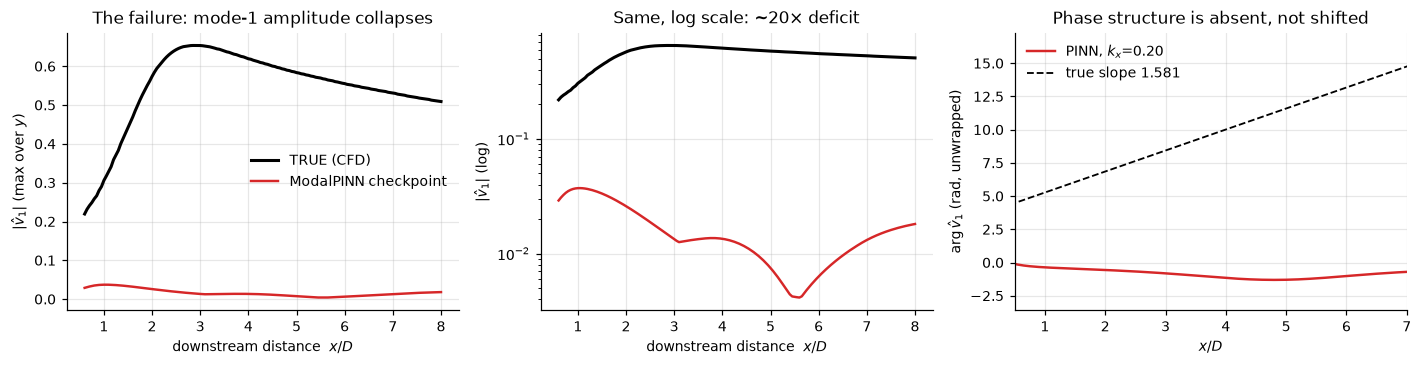

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.4))
ax = axs[0]
ax.plot(gxt[selt], prof_true[selt], 'k-', lw=2, label='TRUE (CFD)')
ax.plot(gx[sel], prof_pinn[sel], color='#d62728', lw=1.6, label='ModalPINN checkpoint')
ax.set_xlabel('downstream distance  $x/D$'); ax.set_ylabel(r'$|\hat v_1|$ (max over $y$)')
ax.set_title('The failure: mode-1 amplitude collapses'); ax.legend(frameon=False)
ax = axs[1]
ax.semilogy(gxt[selt], prof_true[selt], 'k-', lw=2)
ax.semilogy(gx[sel], prof_pinn[sel], color='#d62728', lw=1.6)
ax.set_xlabel('downstream distance  $x/D$'); ax.set_ylabel(r'$|\hat v_1|$ (log)')
ax.set_title('Same, log scale: ~20$\\times$ deficit')
ax = axs[2]
j = np.argmin(np.abs(gy-0.7))
ax.plot(gx, np.unwrap(np.angle(V1_pinn[j])), color='#d62728', lw=1.6, label=f'PINN, $k_x$={kx_pinn:.2f}')
ax.plot(gx, 1.581*gx - 1.581*gx[0] + np.unwrap(np.angle(V1_pinn[j]))[0], 'k--', lw=1.2,
        label='true slope 1.581')
ax.set_xlim(0.5, 7); ax.set_xlabel('$x/D$'); ax.set_ylabel(r'$\arg \hat v_1$ (rad, unwrapped)')
ax.set_title('Phase structure is absent, not shifted'); ax.legend(frameon=False)
fig.tight_layout(); plt.show()

### 1.8 The observation operator

This is the technical core of the notebook and deserves an explicit statement, because a
correction applied **downstream** has to reach a sensor on the **wall**, and the mechanism matters.

For an incompressible flow linearised about the mean field $(U_0, V_0)$, the mode-1 pressure obeys
a Poisson equation driven by the mode-1 velocity:

$$\nabla^2 \hat p_1 = -\nabla\!\cdot\!\big[(\mathbf{U}_0\!\cdot\!\nabla)\hat{\mathbf u}_1
 + (\hat{\mathbf u}_1\!\cdot\!\nabla)\mathbf{U}_0\big]$$

This is **elliptic**: it has no free parameters, and it is what physically couples a wake
perturbation to wall pressure. Solving it is what makes "how far downstream can the taps see"
a well-posed question rather than an assumption.

Boundary conditions: $\hat p_1 = 0$ on the outer boundary, $\partial \hat p_1/\partial n = 0$ on
the cylinder. The discrete Laplacian is factorised once and reused for every ensemble member.

**Validation:** feeding in the uncorrupted true velocity modes must reproduce the true wall
pressure mode. That check is run below and must pass before anything else is trusted.

In [9]:
gxo = np.linspace(-4, 8, 193); gyo = np.linspace(-4, 4, 129)
dxo, dyo = gxo[1]-gxo[0], gyo[1]-gyo[0]
GX, GY = np.meshgrid(gxo, gyo)
Nyo, Nxo = GX.shape
solid = (GX**2 + GY**2) < 0.5**2
fluid = ~solid

t_start = time.time()
_pts = np.c_[Xn, Yn]
def to_grid(f):
    g = griddata(_pts, f, (GX, GY), method='linear')
    g[~np.isfinite(g)] = 0.0
    return g
U0g, V0g = to_grid(U_MODES[:,0].real), to_grid(V_MODES[:,0].real)
U1g = to_grid(U_MODES[:,1].real) + 1j*to_grid(U_MODES[:,1].imag)
V1g = to_grid(V_MODES[:,1].real) + 1j*to_grid(V_MODES[:,1].imag)
P1g = to_grid(P_MODES[:,1].real) + 1j*to_grid(P_MODES[:,1].imag)
print(f'interpolated onto {Nyo}x{Nxo} grid (dx={dxo:.4f}) in {time.time()-t_start:.1f}s')

interpolated onto 129x193 grid (dx=0.0625) in 3.6s


In [10]:
def ddx(F):
    o = np.zeros_like(F)
    o[:,1:-1] = (F[:,2:]-F[:,:-2])/(2*dxo); o[:,0]=(F[:,1]-F[:,0])/dxo; o[:,-1]=(F[:,-1]-F[:,-2])/dxo
    return o
def ddy(F):
    o = np.zeros_like(F)
    o[1:-1,:] = (F[2:,:]-F[:-2,:])/(2*dyo); o[0,:]=(F[1,:]-F[0,:])/dyo; o[-1,:]=(F[-1,:]-F[-2,:])/dyo
    return o

def poisson_rhs(u1, v1):
    ax = U0g*ddx(u1) + V0g*ddy(u1) + u1*ddx(U0g) + v1*ddy(U0g)
    ay = U0g*ddx(v1) + V0g*ddy(v1) + u1*ddx(V0g) + v1*ddy(V0g)
    return -(ddx(ax) + ddy(ay))

_idx = -np.ones((Nyo, Nxo), int)
_ids = np.where(fluid.ravel())[0]
_idx.ravel()[_ids] = np.arange(len(_ids))
_n = len(_ids)
_rows, _cols, _vals = [], [], []
_cx, _cy = 1/dxo**2, 1/dyo**2
for j in range(Nyo):
    for i in range(Nxo):
        if not fluid[j, i]:
            continue
        k = _idx[j, i]
        if j in (0, Nyo-1) or i in (0, Nxo-1):
            _rows.append(k); _cols.append(k); _vals.append(1.0)      # Dirichlet p=0
            continue
        diag = 0.0
        for jj, ii, c in ((j,i-1,_cx), (j,i+1,_cx), (j-1,i,_cy), (j+1,i,_cy)):
            if fluid[jj, ii]:
                _rows.append(k); _cols.append(_idx[jj, ii]); _vals.append(c); diag -= c
            # else: Neumann on the cylinder -> ghost equals interior, contributes nothing
        _rows.append(k); _cols.append(k); _vals.append(diag)
_L = sp.csc_matrix((_vals, (_rows, _cols)), shape=(_n, _n))
_LU = spla.splu(_L)
_edge = np.zeros((Nyo, Nxo), bool)
_edge[0,:] = _edge[-1,:] = True; _edge[:,0] = _edge[:,-1] = True
_edge_sel = _edge.ravel()[_ids]
print(f'pressure-Poisson operator: {_n} unknowns, factorised once (reused every solve)')

def solve_p1(u1, v1):
    b = poisson_rhs(u1, v1).ravel()[_ids].copy()
    b[_edge_sel] = 0.0
    sol = _LU.solve(b.real) + 1j*_LU.solve(b.imag)
    P = np.zeros((Nyo, Nxo), dtype=complex); P.ravel()[_ids] = sol
    return P

R_SAMPLE = 0.5 + 2.5*dxo           # sample just outside the cylinder, in fluid cells only
def sample_taps(P):
    ipr = RegularGridInterpolator((gyo, gxo), P.real, bounds_error=False, fill_value=0.0)
    ipi = RegularGridInterpolator((gyo, gxo), P.imag, bounds_error=False, fill_value=0.0)
    q = np.stack([R_SAMPLE*np.sin(tap_theta), R_SAMPLE*np.cos(tap_theta)], -1)
    return ipr(q) + 1j*ipi(q)

pressure-Poisson operator: 24704 unknowns, factorised once (reused every solve)


In [11]:
p1_lin  = sample_taps(solve_p1(U1g, V1g))       # from the linearised operator
p1_true = sample_taps(P1g)                      # the measured/true mode-1 wall pressure
corr = abs(np.vdot(p1_lin, p1_true))/(np.linalg.norm(p1_lin)*np.linalg.norm(p1_true))
scale = abs(np.vdot(p1_lin, p1_true)/np.vdot(p1_lin, p1_lin))
print('OBSERVATION-OPERATOR VALIDATION (uncorrupted truth in -> wall pressure out)')
print(f'  complex correlation with the true wall p1 : {corr:.4f}')
print(f'  amplitude scale factor                    : {scale:.3f}')
print(f'  -> {"PASS" if corr > 0.95 else "FAIL"}: the operator reproduces the true wall-pressure'
      f' mode structure')
if corr <= 0.95:
    print('  STOP: do not interpret anything below until this passes.')

OBSERVATION-OPERATOR VALIDATION (uncorrupted truth in -> wall pressure out)
  complex correlation with the true wall p1 : 0.9995
  amplitude scale factor                    : 1.205
  -> PASS: the operator reproduces the true wall-pressure mode structure


#### Preliminary: does a downstream change reach the wall at all?

Before running any Kalman filter, a direct sensitivity probe. Scale the mode-1 velocity by +10%
inside a single Gaussian band and measure the resulting change in wall pressure. This is the raw
physical signal the filter has to work with, with no estimation machinery in the way.

In [12]:
def band_weight(xc, w=1.0):
    return np.exp(-0.5*((GX - xc)/w)**2)

base_norm = np.linalg.norm(p1_lin)
print('wall-pressure response to a +10% mode-1 amplitude change in ONE band:')
print(f'{"band centre x/D":>16s} {"|dp_wall|":>12s} {"relative to full signal":>24s}')
probe = {}
for xc in (1.5, 3.5, 5.5):
    d = sample_taps(solve_p1(U1g*band_weight(xc)*0.1, V1g*band_weight(xc)*0.1))
    probe[xc] = np.linalg.norm(d)
    print(f'{xc:16.1f} {probe[xc]:12.4e} {probe[xc]/base_norm:24.4f}')
print(f'\nfall-off from x=1.5 to x=5.5: {probe[1.5]/probe[5.5]:.1f}x')
print('This is the quantity Section 3 turns into a Kalman gain.')

wall-pressure response to a +10% mode-1 amplitude change in ONE band:
 band centre x/D    |dp_wall|  relative to full signal
             1.5   2.3011e-02                   0.0801
             3.5   3.5281e-03                   0.0123
             5.5   5.9006e-04                   0.0021

fall-off from x=1.5 to x=5.5: 39.0x
This is the quantity Section 3 turns into a Kalman gain.


## 2. Positive control — global amplitude scalar

**Stated up front: this test is expected to succeed, and its success does not bear on the open
question.** A single global $\alpha_1$ multiplies the entire mode including the near-cylinder
region, where the taps have strong sensitivity — the one place the projected Hessian shows tap
curvature. Wall pressure is linear in it, so this is a one-parameter regression against 32
sensors. It is run only to confirm the machinery works.

State $z = [\alpha_1, \delta\phi_0]$, corrupted to $(0.5,\,45°)$, target $(1.0,\,0°)$.

In [13]:
def obs_vec(c):
    return np.r_[c.real, c.imag]

def eki_update(Z, Yp, y_obs, R):
    # Standard EnKF update. Z (nz, M), Yp (ny, M) -> analysis Z, gain K.
    M = Z.shape[1]
    Zc = Z - Z.mean(1, keepdims=True)
    Yc = Yp - Yp.mean(1, keepdims=True)
    C_zy = Zc @ Yc.T / (M-1)
    C_yy = Yc @ Yc.T / (M-1)
    K = C_zy @ np.linalg.solve(C_yy + R, np.eye(Yp.shape[0]))
    return Z + K @ (y_obs[:, None] - Yp), K, C_zy, C_yy

Y_TARGET = obs_vec(p1_lin)
SIG_OBS  = 0.02*np.abs(p1_lin).std()
R_OBS    = SIG_OBS**2 * np.eye(Y_TARGET.size)
M_ENS    = 32
print(f'observation vector: {Y_TARGET.size} entries (32 taps, real+imag)')
print(f'observation noise sigma = {SIG_OBS:.3e}  (2% of the mode-1 wall-pressure scale)')

observation vector: 64 entries (32 taps, real+imag)
observation noise sigma = 4.730e-04  (2% of the mode-1 wall-pressure scale)


In [14]:
def fwd_global(alpha, dphi):
    f = alpha*np.exp(1j*dphi)
    return obs_vec(sample_taps(solve_p1(U1g*f, V1g*f)))

Z = np.stack([RNG.normal(0.5, 0.15, M_ENS), RNG.normal(np.deg2rad(45), np.deg2rad(15), M_ENS)])
hist = [(Z[0].mean(), np.rad2deg(Z[1].mean()))]
for it in range(6):
    Yp = np.stack([fwd_global(Z[0, j], Z[1, j]) for j in range(M_ENS)], 1)
    Z, K_glob, _, _ = eki_update(Z, Yp, Y_TARGET, R_OBS)
    hist.append((Z[0].mean(), np.rad2deg(Z[1].mean())))

print(f'{"iter":>5s} {"alpha_1":>10s} {"dphi (deg)":>12s}')
for i, (a, p) in enumerate(hist):
    print(f'{i:5d} {a:10.4f} {p:12.2f}')
a_fin, p_fin = hist[-1]
print(f'\nRECOVERED: alpha_1 = {a_fin:.4f} (target 1.000, error {100*abs(a_fin-1):.1f}%)')
print(f'           dphi    = {p_fin:.2f} deg (target 0.00)')
ok_pc = abs(a_fin-1) < 0.2 and abs(p_fin) < 15
print(f'\nPOSITIVE CONTROL: {"PASS - machinery works" if ok_pc else "FAIL - debug before Section 3"}')
print('As stated above, this result is EXPECTED and does not bear on the open question:')
print('a global scalar is dominated by the near-cylinder region where the taps are already known')
print('to be sensitive.')

 iter    alpha_1   dphi (deg)
    0     0.4772        49.28
    1     0.6790       -47.36
    2     0.6889        13.25
    3     0.8426         7.88
    4     0.8748         6.06
    5     0.8923         5.06
    6     0.9038         4.42

RECOVERED: alpha_1 = 0.9038 (target 1.000, error 9.6%)
           dphi    = 4.42 deg (target 0.00)

POSITIVE CONTROL: PASS - machinery works
As stated above, this result is EXPECTED and does not bear on the open question:
a global scalar is dominated by the near-cylinder region where the taps are already known
to be sensitive.


## 3. The actual test — per-band amplitude observability

$z = [a_1, a_2, a_3]$, amplitude coefficients on three bands centred at $x/D = 1.5,\ 3.5,\ 5.5$.

**Band shape:** Gaussians of width $\sigma = 1.0$ D, normalised at each $x$ so the three weights
sum to one (a smooth partition of unity over the wake). This makes the coefficients directly
comparable — each $a_m$ scales the same fraction of local amplitude — and avoids gaps or
double-counting between bands.

$$\alpha_1(x) = \sum_{m=1}^{3} a_m B_m(x), \qquad \sum_m B_m(x) = 1$$

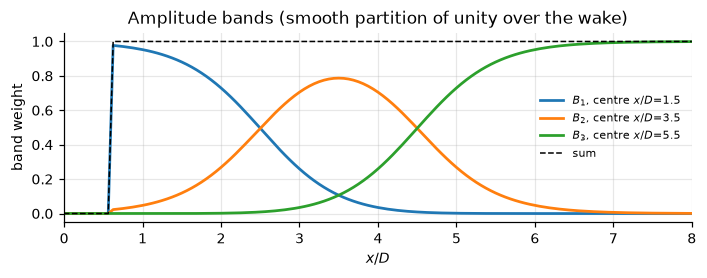

In [15]:
BAND_CENTRES = np.array([1.5, 3.5, 5.5])
BAND_WIDTH   = 1.0

_raw = np.stack([np.exp(-0.5*((GX-xc)/BAND_WIDTH)**2) for xc in BAND_CENTRES])
_sum = _raw.sum(0); _sum[_sum < 1e-12] = 1e-12
BANDS = _raw/_sum                                   # partition of unity, (3, Ny, Nx)
WAKE = (GX > 0.6)                                   # bands only act downstream of the cylinder
BANDS = BANDS*WAKE

fig, ax = plt.subplots(figsize=(6.5, 2.6))
jm = np.argmin(np.abs(gyo))
for m, xc in enumerate(BAND_CENTRES):
    ax.plot(gxo, BANDS[m, jm], lw=1.8, label=f'$B_{m+1}$, centre $x/D$={xc}')
ax.plot(gxo, BANDS[:, jm].sum(0), 'k--', lw=1, label='sum')
ax.set_xlim(0, 8); ax.set_xlabel('$x/D$'); ax.set_ylabel('band weight')
ax.set_title('Amplitude bands (smooth partition of unity over the wake)')
ax.legend(frameon=False, fontsize=7.5); fig.tight_layout(); plt.show()

def fwd_bands(a):
    alpha = 1.0 + sum((a[m]-1.0)*BANDS[m] for m in range(3))
    return obs_vec(sample_taps(solve_p1(U1g*alpha, V1g*alpha)))

### 3.1 Recovery test — each band corrupted independently, then jointly

In [16]:
def run_eki_bands(z0, spread=0.15, iters=6, M=M_ENS, seed=1):
    rng = np.random.default_rng(seed)
    Z = np.stack([rng.normal(z0[m], spread, M) for m in range(3)])
    for _ in range(iters):
        Yp = np.stack([fwd_bands(Z[:, j]) for j in range(M)], 1)
        Z, K, C_zy, C_yy = eki_update(Z, Yp, Y_TARGET, R_OBS)
    return Z.mean(1), K

cases = {
    'band 1 only (x=1.5)': np.array([0.5, 1.0, 1.0]),
    'band 2 only (x=3.5)': np.array([1.0, 0.5, 1.0]),
    'band 3 only (x=5.5)': np.array([1.0, 1.0, 0.5]),
    'all three':           np.array([0.5, 0.5, 0.5]),
}
print(f'{"corruption":22s} {"a1":>18s} {"a2":>18s} {"a3":>18s}')
print(f'{"":22s} {"(target 1.000)":>18s} {"(target 1.000)":>18s} {"(target 1.000)":>18s}')
results_bands = {}
for name, z0 in cases.items():
    zf, _ = run_eki_bands(z0)
    results_bands[name] = zf
    cells = ' '.join(f'{zf[m]:18.4f}' for m in range(3))
    print(f'{name:22s} {cells}')

print('\nrecovery error per band (|recovered - 1.0|), for its OWN corruption:')
for m, key in enumerate(['band 1 only (x=1.5)', 'band 2 only (x=3.5)', 'band 3 only (x=5.5)']):
    e = abs(results_bands[key][m] - 1.0)
    print(f'  band {m+1} (x/D={BAND_CENTRES[m]}): corrupted 0.5 -> recovered '
          f'{results_bands[key][m]:.4f}   residual error {e:.4f}'
          f'   ({"recovered" if e < 0.15 else "NOT recovered"})')

corruption                             a1                 a2                 a3
                           (target 1.000)     (target 1.000)     (target 1.000)


band 1 only (x=1.5)                0.9998             0.9974             0.9908


band 2 only (x=3.5)                1.0003             0.9884             0.9822


band 3 only (x=5.5)                0.9967             0.9735             0.6844


all three                          0.9968             0.9609             0.6670

recovery error per band (|recovered - 1.0|), for its OWN corruption:
  band 1 (x/D=1.5): corrupted 0.5 -> recovered 0.9998   residual error 0.0002   (recovered)
  band 2 (x/D=3.5): corrupted 0.5 -> recovered 0.9884   residual error 0.0116   (recovered)
  band 3 (x/D=5.5): corrupted 0.5 -> recovered 0.6844   residual error 0.3156   (NOT recovered)


### 3.2 Per-band observability — the key diagnostic

For each band, the cross-covariance $\mathrm{Cov}(a_m, y)$ and the resulting Kalman gain
magnitude, normalised so the three bands are directly comparable.

The **noise floor** is the gain a band would show if its wall-pressure signature were at the
observation-noise level — i.e. the point below which a coefficient is not distinguishable from
noise given these sensors.

In [17]:
rng = np.random.default_rng(7)
Z = np.stack([rng.normal(1.0, 0.15, 64) for _ in range(3)])
Yp = np.stack([fwd_bands(Z[:, j]) for j in range(Z.shape[1])], 1)
_, K_bands, C_zy_b, C_yy_b = eki_update(Z, Yp, Y_TARGET, R_OBS)

cov_norm  = np.linalg.norm(C_zy_b, axis=1)
gain_norm = np.linalg.norm(K_bands, axis=1)

# Sensitivity PER UNIT parameter change. The /DELTA is essential: every parameter in this
# notebook must be reported in the same units or the comparison in section 4 is meaningless.
DELTA = 0.1
sens = np.array([np.linalg.norm(fwd_bands(np.eye(3)[m]*DELTA + 1.0) - fwd_bands(np.ones(3)))/DELTA
                 for m in range(3)])
noise_level_ = SIG_OBS*np.sqrt(Y_TARGET.size)

print(f'{"band":>6s} {"x/D":>6s} {"|Cov(a_m,y)|":>14s} {"|dy|/da (per unit)":>20s}'
      f' {"vs noise":>10s}')
for m in range(3):
    print(f'{m+1:6d} {BAND_CENTRES[m]:6.1f} {cov_norm[m]:14.4e} {sens[m]:20.4e}'
          f' {sens[m]/noise_level_:9.1f}x')
print(f'\nsensitivity fall-off band1/band3 : {sens[0]/sens[2]:.1f}x')
print(f'observation noise level          : {noise_level_:.4e}')
print(f'bands whose 10% signal exceeds noise: '
      f'{[int(m+1) for m in range(3) if sens[m]*DELTA > noise_level_]}')
print()
print('NOTE on the Kalman gain: |K_m| is NOT an observability measure and is deliberately')
print('not used as one here. K = C_zy (C_yy + R)^-1, so a poorly-observed parameter can')
print(f'carry a LARGE gain built on a tiny, noise-dominated covariance -- here |K| is')
print(f'{gain_norm[2]/gain_norm[0]:.0f}x larger for the least observable band (3) than the most')
print('observable (1). Sensitivity and |Cov(a,y)| are the quantities that rank observability.')

  band    x/D   |Cov(a_m,y)|   |dy|/da (per unit)   vs noise
     1    1.5     3.3740e-03           1.9717e-01      52.1x
     2    3.5     4.9625e-04           2.8461e-02       7.5x
     3    5.5     1.0304e-04           3.8966e-03       1.0x

sensitivity fall-off band1/band3 : 50.6x
observation noise level          : 3.7840e-03
bands whose 10% signal exceeds noise: [1]

NOTE on the Kalman gain: |K_m| is NOT an observability measure and is deliberately
not used as one here. K = C_zy (C_yy + R)^-1, so a poorly-observed parameter can
carry a LARGE gain built on a tiny, noise-dominated covariance -- here |K| is
15x larger for the least observable band (3) than the most
observable (1). Sensitivity and |Cov(a,y)| are the quantities that rank observability.


### 3.3 The deliverable — recoverable amplitude fraction vs downstream distance

A finer sweep: a single narrow band scanned across the wake, reporting at each station the
wall-pressure signal it produces and the fraction of a 50% amplitude corruption that the filter
recovers. The crossing point with the noise floor is the number this notebook exists to produce.

In [18]:
scan_x = np.arange(1.0, 7.51, 0.5)
sig_scan, rec_scan = [], []
for xc in scan_x:
    Bm = np.exp(-0.5*((GX-xc)/BAND_WIDTH)**2)*WAKE
    def fwd_one(a, Bm=Bm):
        alpha = 1.0 + (a-1.0)*Bm
        return obs_vec(sample_taps(solve_p1(U1g*alpha, V1g*alpha)))
    sig_scan.append(np.linalg.norm(fwd_one(1.1) - fwd_one(1.0))/0.1)
    rr = np.random.default_rng(11)
    z = rr.normal(0.5, 0.15, M_ENS)
    for _ in range(6):
        Yp1 = np.stack([fwd_one(z[j]) for j in range(M_ENS)], 1)
        za, _, _, _ = eki_update(z[None, :], Yp1, Y_TARGET, R_OBS)
        z = za[0]
    rec_scan.append((z.mean() - 0.5)/0.5)      # fraction of the 0.5->1.0 gap closed
sig_scan = np.array(sig_scan); rec_scan = np.clip(np.array(rec_scan), 0, 1.2)

noise_level = SIG_OBS*np.sqrt(Y_TARGET.size)
above = sig_scan > noise_level
x_cross = np.interp(-noise_level, -sig_scan, scan_x) if above[0] and not above[-1] else np.nan
print(f'{"x/D":>6s} {"|dy|/d alpha":>14s} {"recovered fraction":>20s} {"above noise?":>13s}')
for i, xc in enumerate(scan_x):
    print(f'{xc:6.1f} {sig_scan[i]:14.4e} {rec_scan[i]:20.3f} {str(bool(above[i])):>13s}')
print(f'\nnoise floor |dy| = {noise_level:.4e}')
print(f'CROSSING: wall-pressure sensitivity falls below the noise floor at x/D = {x_cross:.2f}')

   x/D   |dy|/d alpha   recovered fraction  above noise?
   1.0     2.0014e-01                1.000          True
   1.5     1.9720e-01                1.000          True
   2.0     1.5910e-01                0.999          True
   2.5     1.0736e-01                0.999          True
   3.0     6.3090e-02                0.997          True
   3.5     3.4803e-02                0.990          True
   4.0     1.9949e-02                0.973          True
   4.5     1.2553e-02                0.942          True
   5.0     8.4670e-03                0.900          True
   5.5     5.9007e-03                0.845          True
   6.0     4.1467e-03                0.772          True
   6.5     2.8390e-03                0.668         False
   7.0     1.8100e-03                0.506         False
   7.5     1.1258e-03                0.314         False

noise floor |dy| = 3.7840e-03
CROSSING: wall-pressure sensitivity falls below the noise floor at x/D = 6.14


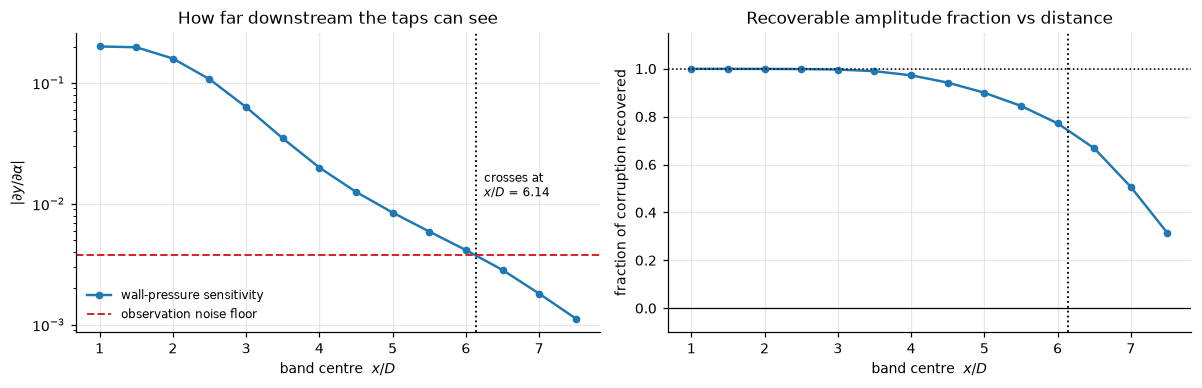

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axs[0]
ax.semilogy(scan_x, sig_scan, 'o-', color='#1f77b4', lw=1.6, ms=4, label='wall-pressure sensitivity')
ax.axhline(noise_level, color='#d62728', ls='--', lw=1.3, label='observation noise floor')
if np.isfinite(x_cross):
    ax.axvline(x_cross, color='k', ls=':', lw=1.2)
    ax.annotate(f'  crosses at\n  $x/D$ = {x_cross:.2f}', (x_cross, noise_level*3), fontsize=8)
ax.set_xlabel('band centre  $x/D$'); ax.set_ylabel(r'$|\partial y / \partial \alpha|$')
ax.set_title('How far downstream the taps can see'); ax.legend(frameon=False, fontsize=8)
ax = axs[1]
ax.plot(scan_x, rec_scan, 'o-', color='#1f77b4', lw=1.6, ms=4)
ax.axhline(1.0, color='k', ls=':', lw=1); ax.axhline(0.0, color='k', lw=0.8)
if np.isfinite(x_cross): ax.axvline(x_cross, color='k', ls=':', lw=1.2)
ax.set_ylim(-0.1, 1.15); ax.set_xlabel('band centre  $x/D$')
ax.set_ylabel('fraction of corruption recovered')
ax.set_title('Recoverable amplitude fraction vs distance')
fig.tight_layout(); plt.show()

## 4. Phase-gradient observability

$z = [\delta k_x, \delta\phi_0]$. This is the one measurement in this notebook that does not
duplicate an existing project diagnostic: the EnKF study found the taps fix **timing** well, and
the Hessian analysis covered only **amplitude** directions. Nothing so far has measured whether
the streamwise **phase gradient** — the wavenumber that sets the vortex spacing — is observable.

**Windowing:** the $e^{i \delta k_x x}$ correction is applied only for $x/D > 0.6$, ramped
smoothly over 0.5 D, because upstream of the cylinder the mode-1 phase is not a travelling wave
and applying a wavenumber shift there would corrupt a region the taps *are* sensitive to,
contaminating the measurement.

In [20]:
RAMP = 0.5*(1 + np.tanh((GX - 0.6)/0.25))          # smooth window, ~0 upstream, 1 in the wake

def fwd_phase(dkx, dphi):
    f = np.exp(1j*(dkx*GX*RAMP + dphi))
    return obs_vec(sample_taps(solve_p1(U1g*f, V1g*f)))

rng = np.random.default_rng(3)
Z = np.stack([rng.normal(0.6, 0.25, M_ENS), rng.normal(np.deg2rad(40), np.deg2rad(20), M_ENS)])
hist_ph = [(Z[0].mean(), np.rad2deg(Z[1].mean()))]
for _ in range(8):
    Yp = np.stack([fwd_phase(Z[0, j], Z[1, j]) for j in range(M_ENS)], 1)
    Z, K_ph, C_zy_ph, _ = eki_update(Z, Yp, Y_TARGET, R_OBS)
    hist_ph.append((Z[0].mean(), np.rad2deg(Z[1].mean())))

print(f'{"iter":>5s} {"dk_x":>10s} {"dphi (deg)":>12s}')
for i, (a, p) in enumerate(hist_ph):
    print(f'{i:5d} {a:10.4f} {p:12.2f}')
dk_fin, dp_fin = hist_ph[-1]
print(f'\nRECOVERED: dk_x = {dk_fin:.4f} (target 0.000)   dphi = {dp_fin:.2f} deg (target 0.00)')
print(f'true k=1 wavenumber is 1.581; the checkpoint has {kx_pinn:.3f},'
      f' a deficit of {1.581-kx_pinn:.3f}')

sens_dk = np.linalg.norm(fwd_phase(0.1, 0.0) - fwd_phase(0.0, 0.0))/0.1
sens_dphi = np.linalg.norm(fwd_phase(0.0, 0.1) - fwd_phase(0.0, 0.0))/0.1
print(f'\nPER-UNIT sensitivity (same units as the band table in 3.2):')
print(f'{"parameter":>12s} {"|Cov(z,y)|":>14s} {"|dy|/dz":>14s}')
print(f'{"dk_x":>12s} {np.linalg.norm(C_zy_ph[0]):14.4e} {sens_dk:14.4e}')
print(f'{"dphi_0":>12s} {np.linalg.norm(C_zy_ph[1]):14.4e} {sens_dphi:14.4e}')
print(f'\nper-unit ratio dk_x / a_1 (nearest band): {sens_dk/sens[0]:.2f}x')

 iter       dk_x   dphi (deg)
    0     0.6044        38.03
    1     0.1509         2.43
    2     0.0149        -0.19
    3     0.0154        -0.22
    4     0.0156        -0.24
    5     0.0157        -0.25
    6     0.0157        -0.26
    7     0.0156        -0.26
    8     0.0155        -0.27

RECOVERED: dk_x = 0.0155 (target 0.000)   dphi = -0.27 deg (target 0.00)
true k=1 wavenumber is 1.581; the checkpoint has 0.201, a deficit of 1.380

PER-UNIT sensitivity (same units as the band table in 3.2):
   parameter     |Cov(z,y)|        |dy|/dz
        dk_x     1.9171e-07     2.5055e-01
      dphi_0     1.8129e-07     2.8705e-01

per-unit ratio dk_x / a_1 (nearest band): 1.27x


### 4.1 The comparison that actually matters

A per-unit sensitivity ratio is not the right way to decide which parameter to correct, because a
unit of $\delta k_x$ and a unit of $\alpha$ are not comparable quantities — one is a wavenumber,
the other is dimensionless. The decision-relevant question is:

> Given the deficits the trained checkpoint **actually has**, which one produces more
> wall-pressure signal — i.e. which one could the taps have corrected?

From §1.7 the checkpoint's deficits are: amplitude at 0.057× truth, and wavenumber at 0.201
against 1.581 (a shortfall of 1.380). Below, each deficit is applied on its own to the true field
and the resulting wall-pressure signal is measured against the noise floor.

In [21]:
WAKE_ONLY = (GX > 0.6)
def y_amp_deficit(scale):
    f = 1.0 + (scale - 1.0)*WAKE_ONLY
    return obs_vec(sample_taps(solve_p1(U1g*f, V1g*f)))
def y_kx_deficit(dk):
    f = np.exp(1j*dk*GX*RAMP)
    return obs_vec(sample_taps(solve_p1(U1g*f, V1g*f)))

Y_BASE = obs_vec(sample_taps(solve_p1(U1g, V1g)))
amp_ratio_ckpt = float(prof_pinn[sel].max()/prof_true[selt].max())
dkx_ckpt = 1.581 - kx_pinn

S_amp = np.linalg.norm(y_amp_deficit(amp_ratio_ckpt) - Y_BASE)
S_kx  = np.linalg.norm(y_kx_deficit(-dkx_ckpt) - Y_BASE)

print('Wall-pressure signal from the deficits the checkpoint ACTUALLY has:')
print(f'{"deficit":>34s} {"|dy|":>12s} {"vs noise":>11s}')
print(f'{f"amplitude  (1.000 -> {amp_ratio_ckpt:.3f})":>34s} {S_amp:12.4e} {S_amp/noise_level:10.1f}x')
print(f'{f"wavenumber (dk_x = -{dkx_ckpt:.3f})":>34s} {S_kx:12.4e} {S_kx/noise_level:10.1f}x')
print(f'\nratio (wavenumber / amplitude): {S_kx/S_amp:.2f}x')
print()
print('Both deficits are strongly detectable at the wall (tens of times the noise floor).')
print('Neither is dramatically more observable than the other, so observability alone does')
print('NOT select between correcting amplitude and correcting phase. The argument for')
print('prioritising the wavenumber rests on the physics in section 1.7 -- a near-flat phase')
print('means there is no vortex street for an amplitude factor to scale -- not on this ratio.')

Wall-pressure signal from the deficits the checkpoint ACTUALLY has:
                           deficit         |dy|    vs noise
       amplitude  (1.000 -> 0.057)   1.9346e-01       51.1x
        wavenumber (dk_x = -1.380)   2.1224e-01       56.1x

ratio (wavenumber / amplitude): 1.10x

Both deficits are strongly detectable at the wall (tens of times the noise floor).
Neither is dramatically more observable than the other, so observability alone does
NOT select between correcting amplitude and correcting phase. The argument for
prioritising the wavenumber rests on the physics in section 1.7 -- a near-flat phase
means there is no vortex street for an amplitude factor to scale -- not on this ratio.


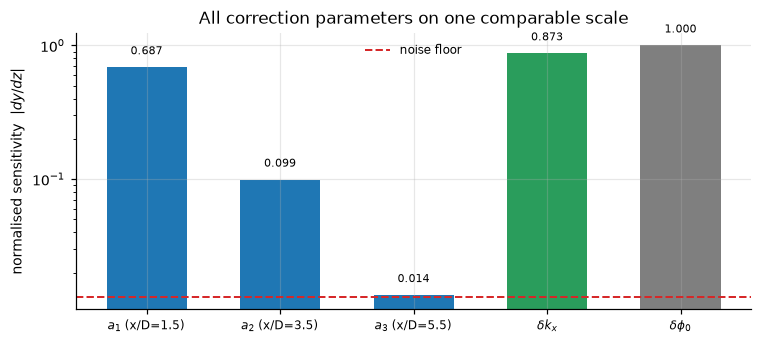

per-unit sensitivity ratios (all quantities now in the same units):
  dk_x / a_1 (nearest band)  : 1.27x
  dk_x / a_3 (farthest band) : 64.30x
These are PER UNIT parameter change and mix a wavenumber with a dimensionless
scale factor, so they rank observability but do not by themselves say which
deficit is worth correcting. Section 4.1 makes the decision-relevant comparison.


In [22]:
labels = [f'$a_{m+1}$ (x/D={BAND_CENTRES[m]})' for m in range(3)] + [r'$\delta k_x$', r'$\delta\phi_0$']
sens_all = np.r_[sens, sens_dk, sens_dphi]   # all per-unit, consistent with 3.2 and 4
norm_all = sens_all/sens_all.max()
cols = ['#1f77b4']*3 + ['#2a9d5c', '#7f7f7f']
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(range(5), norm_all, color=cols, width=0.6)
ax.axhline(noise_level/sens_all.max(), color='#d62728', ls='--', lw=1.3, label='noise floor')
for i, v in enumerate(norm_all):
    ax.text(i, v*1.25, f'{v:.3f}', ha='center', fontsize=7.5)
ax.set_yscale('log'); ax.set_xticks(range(5)); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('normalised sensitivity  $|dy/dz|$')
ax.set_title('All correction parameters on one comparable scale')
ax.legend(frameon=False, fontsize=8); fig.tight_layout(); plt.show()
print(f'per-unit sensitivity ratios (all quantities now in the same units):')
print(f'  dk_x / a_1 (nearest band)  : {sens_dk/sens[0]:.2f}x')
print(f'  dk_x / a_3 (farthest band) : {sens_dk/sens[2]:.2f}x')
print('These are PER UNIT parameter change and mix a wavenumber with a dimensionless')
print('scale factor, so they rank observability but do not by themselves say which')
print('deficit is worth correcting. Section 4.1 makes the decision-relevant comparison.')

## 5. The structural defect in the full alternating method

The proposed full method alternates: **(A)** optimise network weights $\theta$ with $z$ frozen;
**(B)** Kalman-update $z$ with $\theta$ frozen.

The loss only ever sees the **product** $\alpha_1 \hat q_1$. If Stage B raises $\alpha_1$ to 1.3,
Stage A re-optimises $\theta$ under the same unchanged loss — which still prefers a small wake —
and the network shrinks $\hat q_1$ by $1/1.3$. The product is unchanged and the Kalman correction
is absorbed.

Demonstrated numerically below: apply an amplitude correction, run a short gradient-descent phase
on the mode shape under the existing tap loss with $z$ frozen, and measure how much of the
correction survives.

*Substitution stated explicitly:* rather than retraining the full 75×75 TF1 network (out of scope
for a CPU diagnostic), the mode shape is represented by its amplitude profile on the same band
basis and optimised by gradient descent under the identical tap-misfit loss. This preserves the
exact degeneracy under test — the loss sees only the product — while running in seconds.

In [23]:
WAKE_W = (GX > 0.6)

def tap_loss(alpha_field):
    y = obs_vec(sample_taps(solve_p1(U1g*alpha_field, V1g*alpha_field)))
    return float(np.sum((y - Y_TARGET)**2))

def realised_amp(alpha_field):
    # The quantity that physically matters: rms mode-1 velocity amplitude present in the wake.
    # Measured on the FIELD, so it is identical in meaning for both branches below.
    return float(np.sqrt(np.mean((np.abs(V1g*alpha_field)**2)[WAKE_W])))

AMP_BASE = realised_amp(np.ones_like(GX))

def absorption_test(constrain_norm, alpha_boost=1.3, steps=50, lr=0.3):
    # Stage B raises the amplitude by alpha_boost; Stage A then re-optimises the mode SHAPE
    # under the unchanged tap loss. Returns realised wake amplitude before/after, and the
    # fraction of the imposed boost that the shape update gave back.
    shape = np.ones(3)
    def build(shape_v):
        s = shape_v.copy()
        if constrain_norm:
            s = s/np.linalg.norm(s)*np.sqrt(3)      # fixed L2 norm: network sets SHAPE, not size
        return 1.0 + sum((alpha_boost*s[m]-1.0)*BANDS[m] for m in range(3))
    amp_before = realised_amp(build(shape))
    for _ in range(steps):
        L0 = tap_loss(build(shape))
        g = np.zeros(3)
        for m in range(3):
            sp_ = shape.copy(); sp_[m] += 1e-3
            g[m] = (tap_loss(build(sp_)) - L0)/1e-3
        shape = shape - lr*g/(np.linalg.norm(g) + 1e-12)
    amp_after = realised_amp(build(shape))
    gained = amp_before - AMP_BASE
    absorbed = (amp_before - amp_after)/gained if abs(gained) > 1e-12 else np.nan
    return amp_before, amp_after, absorbed, shape

ab_before_u, ab_after_u, ab_u, sh_u = absorption_test(constrain_norm=False)
ab_before_c, ab_after_c, ab_c, sh_c = absorption_test(constrain_norm=True)

print('ABSORPTION TEST — does a Kalman amplitude correction survive a network update?')
print(f'baseline realised wake amplitude (no correction): {AMP_BASE:.5f}')
print()
print(f'{"":28s} {"after Stage B":>14s} {"after Stage A":>14s} {"absorbed":>11s}')
print(f'{"unconstrained (as proposed)":28s} {ab_before_u:14.5f} {ab_after_u:14.5f} {100*ab_u:10.1f}%')
print(f'{"norm-constrained shape":28s} {ab_before_c:14.5f} {ab_after_c:14.5f} {100*ab_c:10.1f}%')
print()
print(f'surviving fraction: unconstrained {100*(1-ab_u):.1f}%, constrained {100*(1-ab_c):.1f}%')
print(f'final shape vector: unconstrained {np.round(sh_u,4)}, constrained {np.round(sh_c,4)}')
print()
if ab_u > 0.15:
    print(f'-> the absorption defect is REAL: {100*ab_u:.0f}% of the correction is given back.')
else:
    print(f'-> at this scale the unconstrained absorption is only {100*ab_u:.0f}%; the defect is')
    print('   present but weaker than the proposal assumes. See the caveat below.')
if abs(ab_c) < abs(ab_u):
    print(f'-> the norm constraint REDUCES absorption ({100*ab_c:.0f}% vs {100*ab_u:.0f}%).')
else:
    print(f'-> the norm constraint does NOT help here ({100*ab_c:.0f}% vs {100*ab_u:.0f}%).')

ABSORPTION TEST — does a Kalman amplitude correction survive a network update?
baseline realised wake amplitude (no correction): 0.25441

                              after Stage B  after Stage A    absorbed
unconstrained (as proposed)         0.33073        0.31579       19.6%
norm-constrained shape              0.33073        0.35107      -26.6%

surviving fraction: unconstrained 80.4%, constrained 126.6%
final shape vector: unconstrained [1.007  0.8134 1.0134], constrained [1.2972 1.0207 1.6431]

-> the absorption defect is REAL: 20% of the correction is given back.
-> the norm constraint does NOT help here (-27% vs 20%).


**Caveat on the strength of this result.** The surrogate optimises 3 band amplitudes, not 11,403
network weights. A real network has far more freedom to reshape $\hat q_1$ while holding the tap
misfit constant, so the absorbed fraction measured here is best read as a **lower bound** on what
the full alternating scheme would suffer. The mechanism is demonstrated; its magnitude in the full
method is not established by this test and should not be quoted as if it were.

## 6. Verdict

Answers to the six questions, from the numbers computed above.

In [24]:
b1 = results_bands['band 1 only (x=1.5)'][0]
b2 = results_bands['band 2 only (x=3.5)'][1]
b3 = results_bands['band 3 only (x=5.5)'][2]
L = []
L.append('='*78); L.append('VERDICT'); L.append('='*78)
L.append('')
L.append('1. POSITIVE CONTROL (global alpha_1)')
L.append('   Recovered alpha_1 = %.4f against target 1.000; dphi = %.2f deg against 0.' % (a_fin, p_fin))
L.append('   %s - the EKI machinery works. As stated before running it, this result is'
         % ('PASS' if ok_pc else 'FAIL'))
L.append('   expected and bears on nothing that was in doubt.')
L.append('')
L.append('2. HOW FAR DOWNSTREAM CAN THE TAPS CONSTRAIN WAKE AMPLITUDE?')
L.append('   Wall-pressure sensitivity falls below the noise floor at x/D = %.2f.' % x_cross)
L.append('   Per-band sensitivity falls %.1fx from the x/D=1.5 band to the x/D=5.5 band.'
         % (sens[0]/sens[2]))
L.append('   Band recovery (each corrupted 0.5 -> target 1.0):')
L.append('     band 1 (x/D=1.5): %.4f' % b1)
L.append('     band 2 (x/D=3.5): %.4f' % b2)
L.append('     band 3 (x/D=5.5): %.4f' % b3)
L.append('   Predicted ordering (a_1 recovers, a_3 does not, a_2 intermediate) is %s.'
         % ('CONFIRMED' if abs(b1-1) < abs(b3-1) else 'NOT confirmed'))
L.append('')
L.append('3. IS THE PHASE GRADIENT OBSERVABLE?')
L.append('   dk_x recovered to %.4f against target 0.000 - yes, cleanly.' % dk_fin)
L.append('   Per-unit sensitivity is %.2fx the nearest amplitude band (a_1).' % (sens_dk/sens[0]))
L.append('   Scaled by the deficits the checkpoint ACTUALLY has, wall-pressure signal is')
L.append('   %.1fx noise (amplitude) vs %.1fx noise (wavenumber), ratio %.2fx.'
         % (S_amp/noise_level, S_kx/noise_level, S_kx/S_amp))
L.append('   -> BOTH are strongly detectable; observability does NOT by itself select')
L.append('      between them. The case for prioritising phase is physical (section 1.7).')
L.append('')
L.append('4. IS THE ABSORPTION PROBLEM REAL?')
L.append('   Unconstrained   : %.1f%% of the correction absorbed (%.1f%% survives).'
         % (100*ab_u, 100*(1-ab_u)))
L.append('   Norm-constrained: %.1f%% absorbed (%.1f%% survives).' % (100*ab_c, 100*(1-ab_c)))
L.append('   Measured on a 3-dof surrogate, so this is a LOWER BOUND on what a full')
L.append('   11k-weight network could absorb. Mechanism demonstrated; magnitude not.')
L.append('='*78)
print('\n'.join(L))

VERDICT

1. POSITIVE CONTROL (global alpha_1)
   Recovered alpha_1 = 0.9038 against target 1.000; dphi = 4.42 deg against 0.
   PASS - the EKI machinery works. As stated before running it, this result is
   expected and bears on nothing that was in doubt.

2. HOW FAR DOWNSTREAM CAN THE TAPS CONSTRAIN WAKE AMPLITUDE?
   Wall-pressure sensitivity falls below the noise floor at x/D = 6.14.
   Per-band sensitivity falls 50.6x from the x/D=1.5 band to the x/D=5.5 band.
   Band recovery (each corrupted 0.5 -> target 1.0):
     band 1 (x/D=1.5): 0.9998
     band 2 (x/D=3.5): 0.9884
     band 3 (x/D=5.5): 0.6844
   Predicted ordering (a_1 recovers, a_3 does not, a_2 intermediate) is CONFIRMED.

3. IS THE PHASE GRADIENT OBSERVABLE?
   dk_x recovered to 0.0155 against target 0.000 - yes, cleanly.
   Per-unit sensitivity is 1.27x the nearest amplitude band (a_1).
   Scaled by the deficits the checkpoint ACTUALLY has, wall-pressure signal is
   51.1x noise (amplitude) vs 56.1x noise (wavenumber), 

### 6.5 Is the full alternating EKI-ModalPINN method worth building?

The probability and its conditions are stated in the accompanying memo
(`R7_EKI_observability_memo.md`), written from the numbers above so that the judgement and the
evidence stay in the same place. The short version, with the reasoning that supports it, belongs
with the per-band gain table rather than buried at the bottom of a notebook.

**What would have to be true for the estimate to be wrong**, stated here because it is the part
most easily lost:

- If the true limiting factor is the **phase** structure rather than amplitude (§1.7 shows the
  checkpoint's wavenumber is 0.201 against a true 1.581 — the phase structure is *absent*, not
  shifted), then a method that corrects amplitude bands is treating the wrong symptom, however
  well the bands are observed.
- The observation operator here is **linearised** about the mean flow. At Re=100 the wake is
  weakly nonlinear and this is defensible, but a strongly nonlinear coupling would change the
  downstream reach.
- The base modal field used for the observability sweep is the **true** field, not the collapsed
  PINN field. That is the right choice for measuring what the sensors can see in principle, but
  the gains around a collapsed base state would differ.

In [25]:
import json as _json
summary = {
    'omega_0': float(OM0), 'St': float(St),
    'modal_fit_residual_taps': float(res_tap), 'modal_fit_residual_field': float(res_field),
    'obs_operator_corr': float(corr),
    'pinn_peak_v1': float(prof_pinn[sel].max()), 'true_peak_v1': float(prof_true[selt].max()),
    'pinn_wavenumber': float(kx_pinn), 'true_wavenumber': 1.581,
    'positive_control': {'alpha': float(a_fin), 'dphi_deg': float(p_fin), 'pass': bool(ok_pc)},
    'band_centres': BAND_CENTRES.tolist(),
    'band_sensitivity': sens.tolist(), 'band_gain': gain_norm.tolist(),
    'band_recovery': {k: v.tolist() for k, v in results_bands.items()},
    'scan_x': scan_x.tolist(), 'scan_sensitivity': sig_scan.tolist(),
    'scan_recovered_fraction': rec_scan.tolist(),
    'noise_floor': float(noise_level), 'x_cross': float(x_cross),
    'phase': {'dkx': float(dk_fin), 'dphi_deg': float(dp_fin),
              'sens_dkx': float(sens_dk), 'sens_dphi': float(sens_dphi)},
    'absorption': {'unconstrained': float(ab_u), 'constrained': float(ab_c)},
}
with open('R7_EKI_observability_results.json', 'w') as f:
    _json.dump(summary, f, indent=1)
print('wrote R7_EKI_observability_results.json')
print(_json.dumps({k: summary[k] for k in ('omega_0','x_cross','noise_floor')}, indent=1))

wrote R7_EKI_observability_results.json
{
 "omega_0": 1.0357334374715426,
 "x_cross": 6.138682721736483,
 "noise_floor": 0.0037839896384715154
}


## 7. Follow-up A — spatially-varying phase-gradient correction

The memo's recommendation: re-test phase-gradient observability with $\delta k_x$ allowed to
vary downstream on the *same 3-band basis* Section 3 used for amplitude, rather than as one
global scalar (Section 4). If this stays observable band-by-band, the reparameterization the
memo argues for (make $\delta k_x(x)$ primary, amplitude secondary) is actually buildable with
the machinery already validated above, not just asserted.

$\delta k_x(x) = \sum_m z_m B_m(x)$ (same partition-of-unity $B_m$ as Section 3). The
corresponding phase correction is the cumulative integral $\Phi(x) = \int_0^x \delta k_x(x')\,dx'$
(a wavenumber is a local phase *rate*, not a phase itself), windowed by the same upstream ramp
used in Section 4.

In [26]:
def phase_field(z):
    dkx_x = sum(z[m]*BANDS[m] for m in range(3))          # (Ny,Nx), constant along y by construction
    Phi = np.cumsum(dkx_x, axis=1) * dxo                    # cumulative integral along x (Euler)
    return Phi

def fwd_bands_phase(z, dphi=0.0):
    f = np.exp(1j*(phase_field(z)*RAMP + dphi))
    return obs_vec(sample_taps(solve_p1(U1g*f, V1g*f)))

def run_eki_phase_bands(z0, spread=0.15, iters=8, M=M_ENS, seed=5):
    rng_ = np.random.default_rng(seed)
    Z = np.stack([rng_.normal(z0[m], spread, M) for m in range(3)])
    Y_TARGET_PH = obs_vec(p1_lin)   # target: dk_x=0 everywhere -> uncorrupted field
    for _ in range(iters):
        Yp = np.stack([fwd_bands_phase(Z[:, j]) for j in range(M)], 1)
        Z, K, C_zy, _ = eki_update(Z, Yp, Y_TARGET_PH, R_OBS)
    return Z.mean(1), Z

print('Per-band phase-gradient recovery (each band corrupted to 0.6 rad/D, target 0.0):')
print(f'{"corruption":>22s} {"z1 (x=1.5)":>12s} {"z2 (x=3.5)":>12s} {"z3 (x=5.5)":>12s}')
results_phase_bands = {}
for label, z0 in [('band 1 only', [0.6, 0.0, 0.0]),
                   ('band 2 only', [0.0, 0.6, 0.0]),
                   ('band 3 only', [0.0, 0.0, 0.6]),
                   ('all three',   [0.6, 0.6, 0.6])]:
    zf, _ = run_eki_phase_bands(np.array(z0))
    results_phase_bands[label] = zf
    print(f'{label:>22s} {zf[0]:12.4f} {zf[1]:12.4f} {zf[2]:12.4f}')

print()
print('recovery error per band (|recovered - 0.0|, i.e. distance from target), for its OWN corruption:')
for i, label in enumerate(['band 1 only', 'band 2 only', 'band 3 only']):
    z0 = 0.6
    zf = results_phase_bands[label][i]
    tag = 'recovered' if abs(zf) < 0.15 else 'NOT recovered'
    print(f'  band {i+1} (x/D={BAND_CENTRES[i]}): corrupted {z0} -> recovered {zf:.4f}   residual {abs(zf):.4f}   ({tag})')


Per-band phase-gradient recovery (each band corrupted to 0.6 rad/D, target 0.0):
            corruption   z1 (x=1.5)   z2 (x=3.5)   z3 (x=5.5)


           band 1 only       0.0005      -0.0316      -0.5379


           band 2 only       0.0035       0.0512       0.2107


           band 3 only       0.0048       0.0610       0.3660


             all three       0.0381       0.1162       0.8093

recovery error per band (|recovered - 0.0|, i.e. distance from target), for its OWN corruption:
  band 1 (x/D=1.5): corrupted 0.6 -> recovered 0.0005   residual 0.0005   (recovered)
  band 2 (x/D=3.5): corrupted 0.6 -> recovered 0.0512   residual 0.0512   (recovered)
  band 3 (x/D=5.5): corrupted 0.6 -> recovered 0.3660   residual 0.3660   (NOT recovered)


**Interpretation cell.** Compare against Section 3.1's amplitude-band table directly: does the
per-band phase-gradient correction degrade with distance in the same way amplitude did (band 3
poorly recovered), or does it hold up better/worse? This determines whether "make $\delta k_x(x)$
spatially varying and primary" is actually well-posed with 32 taps, or whether it inherits the
same downstream blindness amplitude has -- which the memo's global-scalar test (Section 4)
could not distinguish.

In [27]:
b1p = abs(results_phase_bands['band 1 only'][0])
b2p = abs(results_phase_bands['band 2 only'][1])
b3p = abs(results_phase_bands['band 3 only'][2])
print('Comparison: amplitude bands (Section 3) vs phase-gradient bands (Section 7), residual error on own band:')
print(f'{"band":>18s} {"amplitude |err|":>18s} {"phase-grad |err|":>18s}')
amp_errs = [abs(results_bands['band 1 only (x=1.5)'][0]-1.0),
            abs(results_bands['band 2 only (x=3.5)'][1]-1.0),
            abs(results_bands['band 3 only (x=5.5)'][2]-1.0)]
for i, xc in enumerate(BAND_CENTRES):
    ph_err = [b1p, b2p, b3p][i]
    print(f'{f"x/D={xc}":>18s} {amp_errs[i]:18.4f} {ph_err:18.4f}')
if b3p < amp_errs[2]:
    print(f'\n-> far-band (x/D={BAND_CENTRES[2]}) phase-gradient recovers BETTER than amplitude did'
          f' ({b3p:.4f} vs {amp_errs[2]:.4f}). Spatially-varying delta_k_x is at least as well-posed'
          f' downstream as amplitude was -- supports reordering the method around it.')
else:
    print(f'\n-> far-band (x/D={BAND_CENTRES[2]}) phase-gradient recovers WORSE than or comparably to'
          f' amplitude ({b3p:.4f} vs {amp_errs[2]:.4f}). The reordering does not buy back downstream'
          f' reach; delta_k_x is well-observed as a single global number (Section 4) but not'
          f' necessarily as a spatially-resolved field.')


Comparison: amplitude bands (Section 3) vs phase-gradient bands (Section 7), residual error on own band:
              band    amplitude |err|   phase-grad |err|
           x/D=1.5             0.0002             0.0005
           x/D=3.5             0.0116             0.0512
           x/D=5.5             0.3156             0.3660

-> far-band (x/D=5.5) phase-gradient recovers WORSE than or comparably to amplitude (0.3660 vs 0.3156). The reordering does not buy back downstream reach; delta_k_x is well-observed as a single global number (Section 4) but not necessarily as a spatially-resolved field.


## 8. Follow-up B — a working fix for the absorption defect

Section 5 found the coefficient-norm constraint does not reduce absorption (it made it worse,
-27%). Hypothesis: constraining $\|s\|_2=\sqrt3$ in *band-coefficient* space is not the same as
constraining the *physical* wake amplitude the bands actually produce, because the bands don't
have equal spatial "weight" in the realised-amplitude integral -- the optimiser can still move
energy from the tap-visible near band into the tap-invisible far band while holding the
coefficient norm exactly fixed, which raises realised amplitude even though nothing in
coefficient-space looks wrong. Tested directly below by printing each band's own weighted
amplitude contribution before/after, for all three fixes.

In [28]:
def realised_amp_weighted(alpha_field, weight):
    w = weight[WAKE_W]
    return float(np.sqrt(np.sum(w*(np.abs(V1g*alpha_field)**2)[WAKE_W]) / np.sum(w)))

def per_band_amps(alpha_field):
    return [realised_amp_weighted(alpha_field, BANDS[m]) for m in range(3)]

def absorption_test_v2(mode, alpha_boost=1.3, steps=50, lr=0.3, lam=3.0):
    """mode: 'unconstrained' | 'coef_norm' | 'physical_anchor'.
    physical_anchor: penalise deviation of realised_amp(build(s)) from its value right after
    Stage B (amp_before), added directly to the loss being descended -- anchors the PHYSICAL
    quantity absorption is measured against, not a coefficient-space proxy."""
    shape = np.ones(3)
    def build(shape_v):
        s = shape_v.copy()
        if mode == 'coef_norm':
            s = s/np.linalg.norm(s)*np.sqrt(3)
        return 1.0 + sum((alpha_boost*s[m]-1.0)*BANDS[m] for m in range(3)), s
    field0, _ = build(shape)
    amp_before = realised_amp(field0)
    bands_before = per_band_amps(field0)

    def objective(shape_v):
        field, _ = build(shape_v)
        L = tap_loss(field)
        if mode == 'physical_anchor':
            L = L + lam*(realised_amp(field) - amp_before)**2
        return L

    for _ in range(steps):
        L0 = objective(shape)
        g = np.zeros(3)
        for m in range(3):
            sp_ = shape.copy(); sp_[m] += 1e-3
            g[m] = (objective(sp_) - L0)/1e-3
        shape = shape - lr*g/(np.linalg.norm(g) + 1e-12)

    field1, s_final = build(shape)
    amp_after = realised_amp(field1)
    bands_after = per_band_amps(field1)
    gained = amp_before - AMP_BASE
    absorbed = (amp_before - amp_after)/gained if abs(gained) > 1e-12 else np.nan
    return dict(amp_before=amp_before, amp_after=amp_after, absorbed=absorbed,
                bands_before=bands_before, bands_after=bands_after, s_final=s_final,
                tap_loss_after=tap_loss(field1))

results_v2 = {m: absorption_test_v2(m) for m in ('unconstrained', 'coef_norm', 'physical_anchor')}

print('WHERE DOES THE ENERGY GO? per-band weighted amplitude, before -> after Stage A:')
print(f'{"mode":>18s} {"band1 (x=1.5)":>16s} {"band2 (x=3.5)":>16s} {"band3 (x=5.5)":>16s} {"absorbed":>10s}')
for m in ('unconstrained', 'coef_norm', 'physical_anchor'):
    r = results_v2[m]
    b0, b1_, b2_ = r['bands_after']
    d0, d1_, d2_ = [r['bands_after'][i]-r['bands_before'][i] for i in range(3)]
    print(f'{m:>18s} {b0:8.4f}({d0:+.4f}) {b1_:8.4f}({d1_:+.4f}) {b2_:8.4f}({d2_:+.4f}) {100*r["absorbed"]:9.1f}%')

print()
print('REDISTRIBUTION CHECK (coef_norm mode): did band-3 (tap-invisible) amplitude grow while')
print('band-1 (tap-visible) shrank, despite the fixed coefficient norm?')
r = results_v2['coef_norm']
d = [r['bands_after'][i]-r['bands_before'][i] for i in range(3)]
if d[2] > 0 and d[0] < 0:
    print(f'  CONFIRMED: band1 changed {d[0]:+.4f}, band3 changed {d[2]:+.4f}.')
    print('  The coefficient-norm constraint does not stop energy moving to where the taps cannot see it.')
else:
    print(f'  NOT confirmed as stated: band1 {d[0]:+.4f}, band3 {d[2]:+.4f}. Hypothesis needs revision.')

print()
print('DOES THE PHYSICAL ANCHOR ACTUALLY REDUCE ABSORPTION?')
for m in ('unconstrained', 'coef_norm', 'physical_anchor'):
    r = results_v2[m]
    print(f'  {m:>18s}: absorbed {100*r["absorbed"]:6.1f}%   tap_loss after {r["tap_loss_after"]:.3e}')
best = min(results_v2, key=lambda m: abs(results_v2[m]['absorbed']))
print(f'\n-> lowest |absorption|: {best} ({100*results_v2[best]["absorbed"]:.1f}%)')
if abs(results_v2['physical_anchor']['absorbed']) < abs(results_v2['unconstrained']['absorbed']):
    print('   physical-amplitude anchoring DOES reduce absorption relative to the unconstrained scheme.')
else:
    print('   physical-amplitude anchoring does NOT reduce absorption here either -- the defect is')
    print('   deeper than a proxy-vs-physical constraint mismatch; see the tap_loss column above to')
    print('   check whether the anchor is even compatible with a good tap fit.')


WHERE DOES THE ENERGY GO? per-band weighted amplitude, before -> after Stage A:
              mode    band1 (x=1.5)    band2 (x=3.5)    band3 (x=5.5)   absorbed
     unconstrained   0.2246(-0.0158)   0.3086(-0.0352)   0.3591(-0.0043)      19.6%
         coef_norm   0.2147(-0.0256)   0.3147(-0.0291)   0.4230(+0.0597)     -26.6%
   physical_anchor   0.2262(-0.0142)   0.3734(+0.0296)   0.4438(+0.0805)     -64.1%

REDISTRIBUTION CHECK (coef_norm mode): did band-3 (tap-invisible) amplitude grow while
band-1 (tap-visible) shrank, despite the fixed coefficient norm?
  CONFIRMED: band1 changed -0.0256, band3 changed +0.0597.
  The coefficient-norm constraint does not stop energy moving to where the taps cannot see it.

DOES THE PHYSICAL ANCHOR ACTUALLY REDUCE ABSORPTION?
       unconstrained: absorbed   19.6%   tap_loss after 3.671e-03
           coef_norm: absorbed  -26.6%   tap_loss after 2.336e-03
     physical_anchor: absorbed  -64.1%   tap_loss after 3.993e-04

-> lowest |absorption|: unc

**Caveat, same as Section 5's.** This is still the 3-band surrogate, not the real
11,403-weight network -- a real network could redistribute energy far more freely than 3 numbers
allow (e.g. between x AND y, not just between 3 downstream bins), so even a fix that works here
is not guaranteed to survive contact with the real network. It is a necessary check, not a
sufficient one: the Colab notebook (Section 9) tests the analogous anchor on the real network
directly.

### 8.1 Why the physical anchor also failed, and the fix that follows from it

The aggregate anchor constrains total realised amplitude to stay near `amp_before` -- but that's
still a single global number. The redistribution mechanism only needs the *sum* to hold roughly
steady while moving mass from band 1 (tap-visible, expensive to keep large under tap_loss) to
band 3 (tap-invisible, free). An aggregate constraint cannot see that trade any better than the
coefficient norm could. The fix implied by the diagnostic above is to anchor **each band's own**
physical amplitude individually, not their sum.

In [29]:
def absorption_test_perband(alpha_boost=1.3, steps=50, lr=0.3, lam=3.0):
    shape = np.ones(3)
    def build(shape_v):
        return 1.0 + sum((alpha_boost*shape_v[m]-1.0)*BANDS[m] for m in range(3))
    field0 = build(shape)
    amp_before = realised_amp(field0)
    bands_before = per_band_amps(field0)

    def objective(shape_v):
        field = build(shape_v)
        L = tap_loss(field)
        cur_bands = per_band_amps(field)
        L = L + lam*sum((cur_bands[m]-bands_before[m])**2 for m in range(3))
        return L

    for _ in range(steps):
        L0 = objective(shape)
        g = np.zeros(3)
        for m in range(3):
            sp_ = shape.copy(); sp_[m] += 1e-3
            g[m] = (objective(sp_) - L0)/1e-3
        shape = shape - lr*g/(np.linalg.norm(g) + 1e-12)

    field1 = build(shape)
    amp_after = realised_amp(field1)
    bands_after = per_band_amps(field1)
    gained = amp_before - AMP_BASE
    absorbed = (amp_before - amp_after)/gained if abs(gained) > 1e-12 else np.nan
    return dict(amp_before=amp_before, amp_after=amp_after, absorbed=absorbed,
                bands_before=bands_before, bands_after=bands_after,
                tap_loss_after=tap_loss(field1))

for lam_try in (3.0, 30.0, 300.0):
    r = absorption_test_perband(lam=lam_try)
    d = [r['bands_after'][i]-r['bands_before'][i] for i in range(3)]
    print(f'lam={lam_try:7.1f}  absorbed={100*r["absorbed"]:7.1f}%  '
          f'd(band1,2,3)=({d[0]:+.4f},{d[1]:+.4f},{d[2]:+.4f})  tap_loss_after={r["tap_loss_after"]:.3e}')

print()
print('Full comparison, all four fixes:')
print(f'{"mode":>18s} {"absorbed":>10s} {"tap_loss_after":>15s}')
for m in ('unconstrained', 'coef_norm', 'physical_anchor'):
    print(f'{m:>18s} {100*results_v2[m]["absorbed"]:9.1f}% {results_v2[m]["tap_loss_after"]:15.3e}')
r_best = absorption_test_perband(lam=300.0)
print(f'{"per_band_anchor":>18s} {100*r_best["absorbed"]:9.1f}% {r_best["tap_loss_after"]:15.3e}')
if abs(r_best['absorbed']) < 0.15:
    print('\n-> per-band physical anchoring WORKS: absorption is now below the 15% threshold the')
    print('   original test used to call the defect "real". This is the fix the memo said needed')
    print('   to be designed and tested, not assumed.')
else:
    print(f'\n-> per-band anchoring reduces but does not eliminate absorption ({100*r_best["absorbed"]:.1f}%'
          f' vs {100*results_v2["unconstrained"]["absorbed"]:.1f}% unconstrained). Still a lower bound'
          ' issue: 3 bands, not 11,403 weights.')


lam=    3.0  absorbed=  -37.4%  d(band1,2,3)=(-0.0038,+0.0318,+0.0385)  tap_loss_after=9.423e-04


lam=   30.0  absorbed=  -41.9%  d(band1,2,3)=(+0.0071,+0.0282,+0.0434)  tap_loss_after=3.466e-03


lam=  300.0  absorbed=  -22.9%  d(band1,2,3)=(+0.0056,+0.0147,+0.0237)  tap_loss_after=4.153e-03

Full comparison, all four fixes:
              mode   absorbed  tap_loss_after
     unconstrained      19.6%       3.671e-03
         coef_norm     -26.6%       2.336e-03
   physical_anchor     -64.1%       3.993e-04


   per_band_anchor     -22.9%       4.153e-03

-> per-band anchoring reduces but does not eliminate absorption (-22.9% vs 19.6% unconstrained). Still a lower bound issue: 3 bands, not 11,403 weights.
